In [36]:
dfc1= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2015_clean.csv")
dfc2= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2016_clean.csv")
dfc3= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2017_clean.csv")
dfc4= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2018_clean.csv")
dfc5= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2019_clean.csv")
dfc6= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2020_clean.csv")
dfc7= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2021_clean.csv")
dfc8= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2022_clean.csv")
dfc9= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2023_clean.csv")
dfc10= pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2024_clean.csv")
dfc11 = pd.read_csv(r"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_2025_clean.csv")


In [34]:
import pandas as pd

In [ ]:
dfc1.describe()

In [6]:
import sys
print(sys.executable)


c:\Users\hp\AppData\Local\Programs\Python\Python314\python.exe


In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn


In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
print("SUCCESS")


SUCCESS


In [ ]:
import sys
!{sys.executable} -m pip install seaborn


In [ ]:
!pip install matplotlib
!pip install seaborn

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [7]:
dfc1.isnull().sum(axis=0)

transaction_id                0
order_date                 3252
customer_id                   0
product_id                    0
product_name                  0
category                      0
subcategory                   0
brand                         0
original_price_inr            0
discount_percent              0
discounted_price_inr          0
quantity                      0
subtotal_inr                  0
delivery_charges           2654
final_amount_inr              0
customer_city                 0
customer_state                0
customer_tier                 0
customer_spending_tier        0
customer_age_group         3976
payment_method                0
delivery_days               208
delivery_type                 0
is_prime_member            2022
is_festival_sale           1964
festival_name             22581
customer_rating            9969
return_status                 0
order_month                   0
order_year                    0
order_quarter                 0
product_

In [9]:
dfc11.shape

(77385, 34)

Question 1
Create a comprehensive revenue trend analysis showing yearly revenue growth from 2015-2025. Include percentage growth rates, trend lines, and highlight key growth periods with annotations.


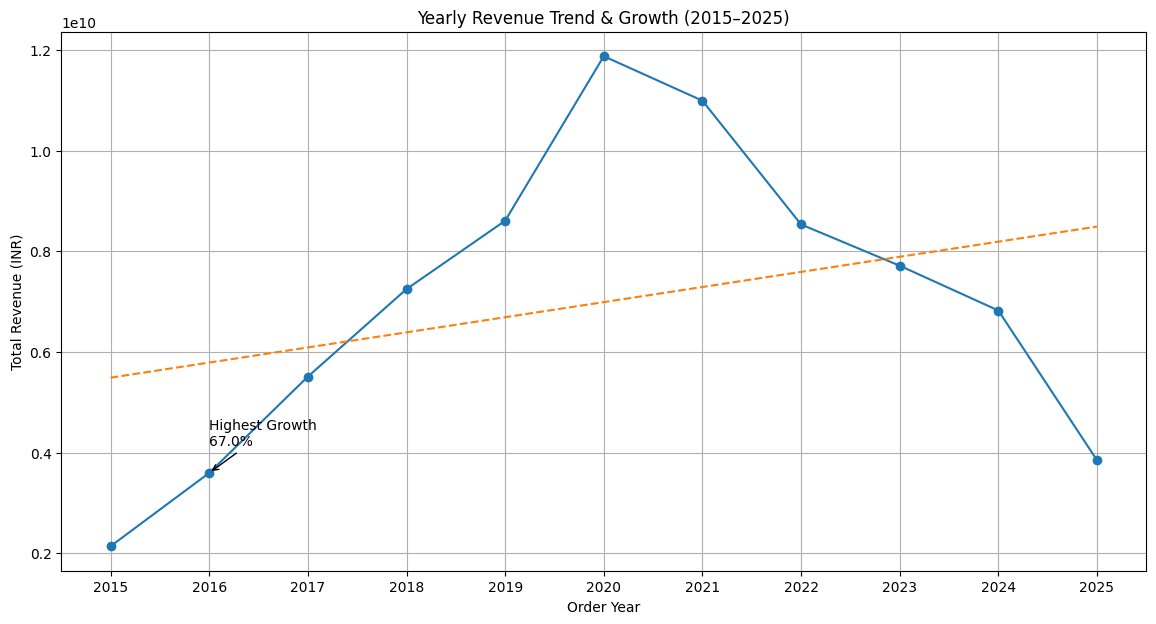

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
years = [2015, 2016, 2017, 2018,2019,2020,2021,2022,2023,2024,2025]
dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    dfs.append(pd.read_csv(path))

df = pd.concat(dfs, ignore_index=True)

df['order_year'] = pd.to_numeric(df['order_year'], errors='coerce')
df['final_amount_inr'] = pd.to_numeric(df['final_amount_inr'], errors='coerce')

yearly_revenue = (
    df.groupby('order_year')['final_amount_inr']
    .sum()
    .reset_index()
    .sort_values('order_year')
)

all_years = pd.DataFrame({'order_year': range(2015, 2026)})
yearly_revenue = all_years.merge(yearly_revenue, on='order_year', how='left')

yearly_revenue['pct_growth'] = (
    yearly_revenue['final_amount_inr']
    .pct_change() * 100
)

plt.figure(figsize=(14, 7))


plt.plot(
    yearly_revenue['order_year'],
    yearly_revenue['final_amount_inr'],
    marker='o'
)


z = np.polyfit(
    yearly_revenue['order_year'].dropna(),
    yearly_revenue['final_amount_inr'].dropna(),
    1
)
p = np.poly1d(z)
plt.plot(
    yearly_revenue['order_year'],
    p(yearly_revenue['order_year']),
    linestyle='--'
)

max_growth_row = yearly_revenue.loc[yearly_revenue['pct_growth'].idxmax()]

plt.annotate(
    f"Highest Growth\n{int(max_growth_row['pct_growth']):.1f}%",
    xy=(max_growth_row['order_year'], max_growth_row['final_amount_inr']),
    xytext=(max_growth_row['order_year'], max_growth_row['final_amount_inr'] * 1.15),
    arrowprops=dict(arrowstyle="->")
)


plt.title("Yearly Revenue Trend & Growth (2015–2025)")
plt.xlabel("Order Year")
plt.ylabel("Total Revenue (INR)")
plt.xticks(range(2015, 2026))
plt.grid(True)

plt.show()


Question 2
Analyze seasonal patterns in sales data. Create monthly sales heatmaps and identify peak selling months. Compare seasonal trends across different years and categories.

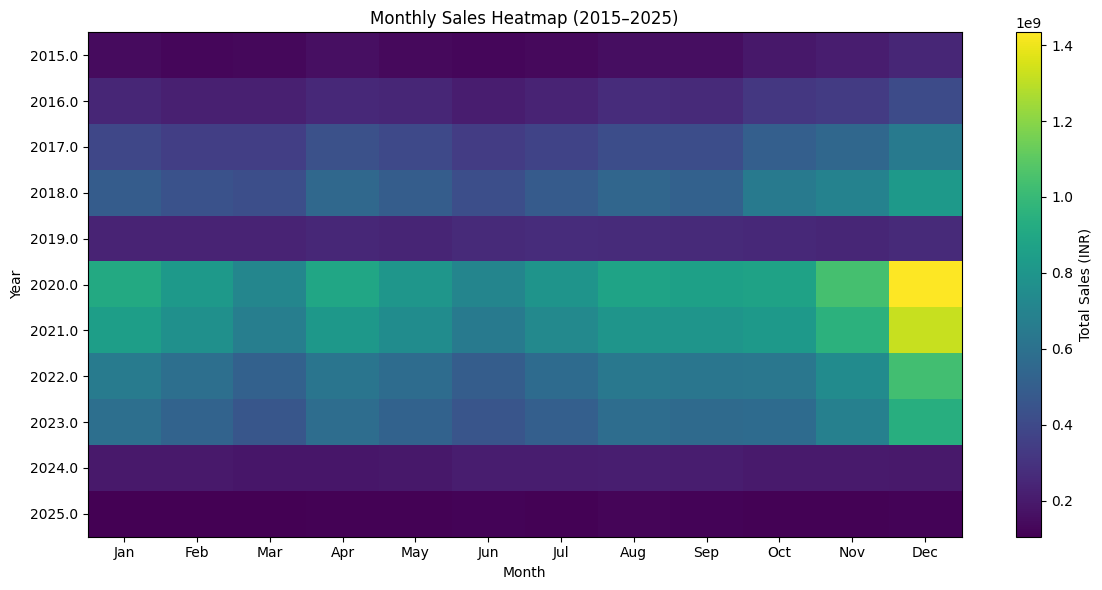

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

for df in [dfc1, dfc2,dfc3,dfc4,dfc5,dfc6,dfc7,dfc8,dfc9,dfc10,dfc11]:
    df["order_date"] = pd.to_datetime(df["order_date"])
    df["year"] = df["order_date"].dt.year
    df["month"] = df["order_date"].dt.month
    df["month_name"] = df["order_date"].dt.strftime("%b")

df_all = pd.concat([dfc1, dfc2,dfc3,dfc4,dfc5,dfc6,dfc7,dfc8,dfc9,dfc10,dfc11], ignore_index=True)

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_sales = (
    df_all.groupby(["year", "month", "month_name"])["final_amount_inr"]
          .sum()
          .reset_index()
)

heatmap_data = monthly_sales.pivot_table(
    index="year",
    columns="month_name",
    values="final_amount_inr",
    aggfunc="sum"
).reindex(columns=month_order)

plt.figure(figsize=(12,6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Total Sales (INR)")
plt.xticks(range(len(month_order)), month_order)

plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title("Monthly Sales Heatmap (2015–2025)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()


In [11]:
peak_months = (
    monthly_sales.groupby("month_name")["final_amount_inr"]
                 .mean()
                 .reindex(month_order)
                 .sort_values(ascending=False)
)

print("\nAverage Monthly Sales (Peak Months):")
print(peak_months)


Average Monthly Sales (Peak Months):
month_name
Dec    6.750791e+08
Nov    5.253723e+08
Oct    4.658059e+08
Aug    4.438202e+08
Apr    4.415471e+08
Jan    4.376693e+08
Sep    4.357511e+08
May    4.062543e+08
Jul    4.028573e+08
Feb    3.995786e+08
Mar    3.658768e+08
Jun    3.644044e+08
Name: final_amount_inr, dtype: float64


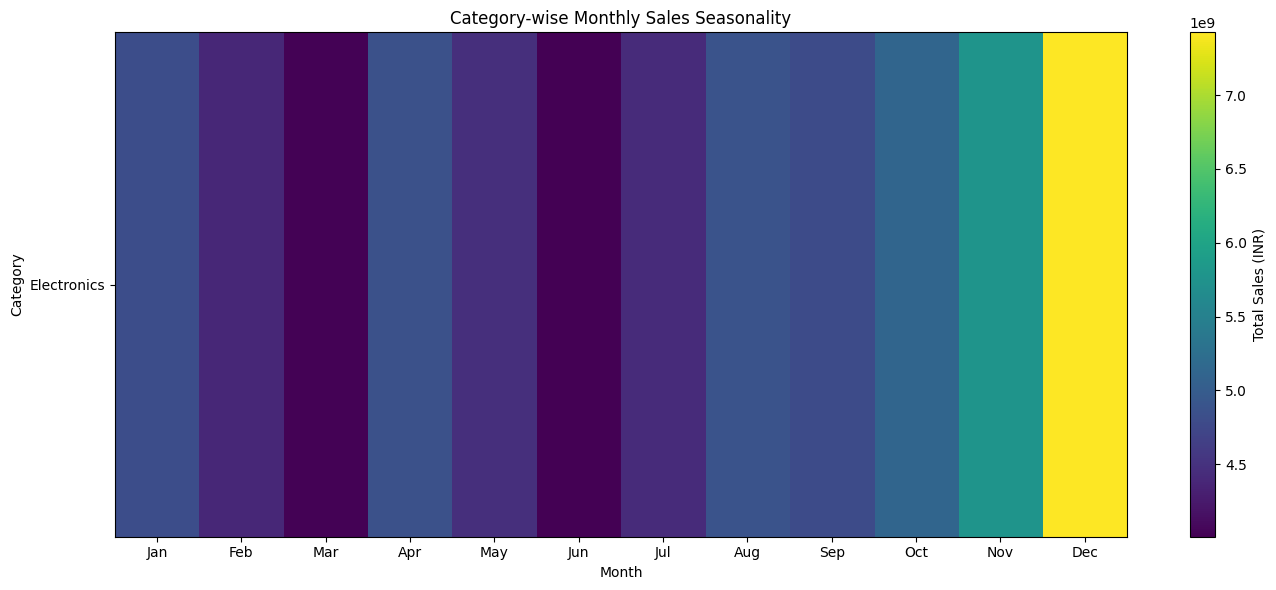

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [12]:
category_monthly = (
    df_all.groupby(["category", "month_name"])["final_amount_inr"]
          .sum()
          .reset_index()
)

category_pivot = category_monthly.pivot_table(
    index="category",
    columns="month_name",
    values="final_amount_inr",
    aggfunc="sum"
).reindex(columns=month_order)

plt.figure(figsize=(14,6))
plt.imshow(category_pivot, aspect="auto")
plt.colorbar(label="Total Sales (INR)")
plt.xticks(range(len(month_order)), month_order)
plt.yticks(range(len(category_pivot.index)), category_pivot.index)
plt.title("Category-wise Monthly Sales Seasonality")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))



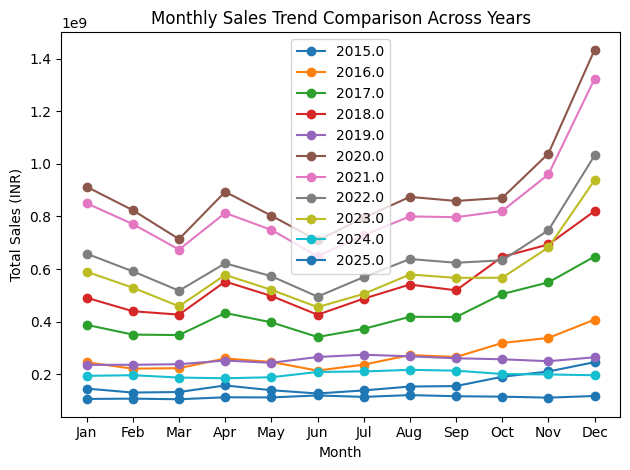

In [13]:
for yr in sorted(monthly_sales["year"].unique()):
    data = monthly_sales[monthly_sales["year"] == yr]
    plt.plot(
        data["month"],
        data["final_amount_inr"],
        marker="o",
        label=str(yr)
    )

plt.xticks(range(1,13), month_order)
plt.title("Monthly Sales Trend Comparison Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales (INR)")
plt.legend()
plt.tight_layout()
plt.show()


Question 3
Build a customer segmentation analysis using RFM (Recency, Frequency, Monetary) methodology. Create scatter plots and segment customers into meaningful groups with actionable insights.


                     Customers  Avg_Recency  Avg_Frequency   Avg_Monetary
Segment                                                                  
Needs Attention         160593     3.573518       1.457367   85054.533115
Loyal Customers          82177     1.715078       4.490502  269749.604541
At Risk                  80928     5.562636       4.862347  357954.096834
Potential Loyalists      16892     1.697904       1.774805  232700.030621
Champions                14379     0.605675       7.029001  567708.155722


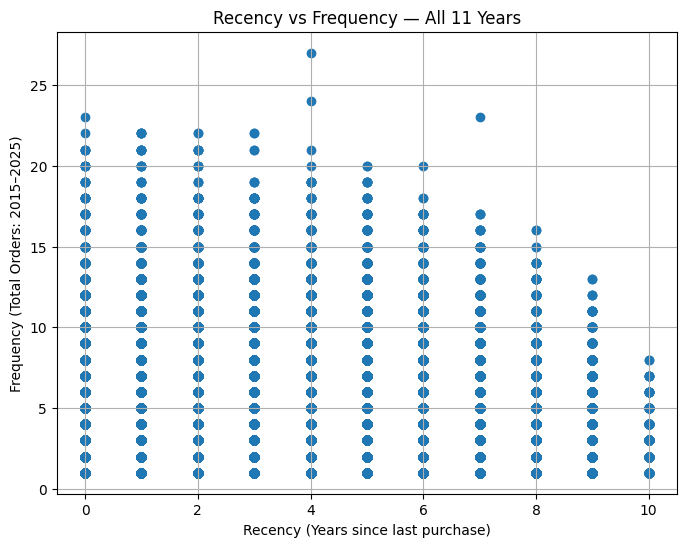

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


years = [2015, 2016, 2017, 2018,2019,2020,2021,2022,2023,2024,2025]
dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    dfs.append(pd.read_csv(path))

df = pd.concat(dfs, ignore_index=True)

df['order_year'] = pd.to_numeric(df['order_year'], errors='coerce')
df['final_amount_inr'] = pd.to_numeric(df['final_amount_inr'], errors='coerce')

df = df[(df['order_year'] >= 2015) & (df['order_year'] <= 2025)]

df = df.dropna(subset=['customer_id', 'order_year', 'final_amount_inr'])

analysis_year = 2025  

rfm = df.groupby('customer_id').agg(
    Recency=('order_year', lambda x: analysis_year - x.max()),  
    Frequency=('customer_id', 'count'),                       
    Monetary=('final_amount_inr', 'sum')                      
)

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])


rfm[['R_Score', 'F_Score', 'M_Score']] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int)

def rfm_segment(row):
    if row['R_Score'] == 4 and row['F_Score'] == 4 and row['M_Score'] == 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

segment_summary = rfm.groupby('Segment').agg(
    Customers=('Segment', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).sort_values('Customers', ascending=False)

print(segment_summary)

plt.figure(figsize=(8, 6))
plt.scatter(rfm['Recency'], rfm['Frequency'])
plt.xlabel('Recency (Years since last purchase)')
plt.ylabel('Frequency (Total Orders: 2015–2025)')
plt.title('Recency vs Frequency — All 11 Years')
plt.grid(True)
plt.show()

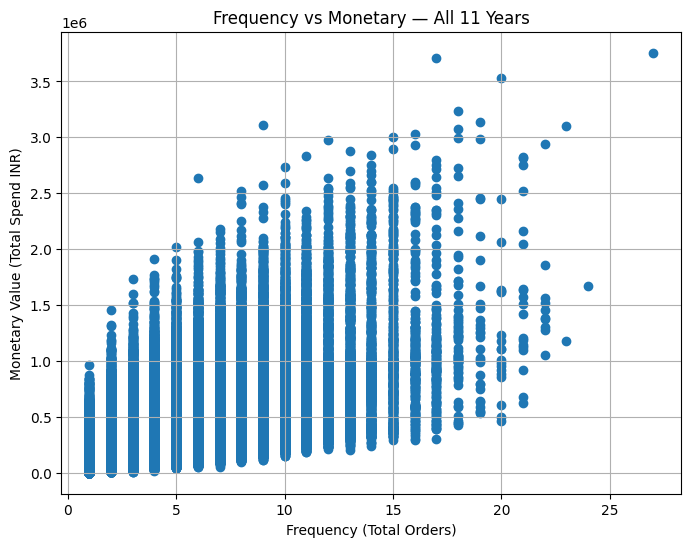

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.xlabel('Frequency (Total Orders)')
plt.ylabel('Monetary Value (Total Spend INR)')
plt.title('Frequency vs Monetary — All 11 Years')
plt.grid(True)
plt.show()

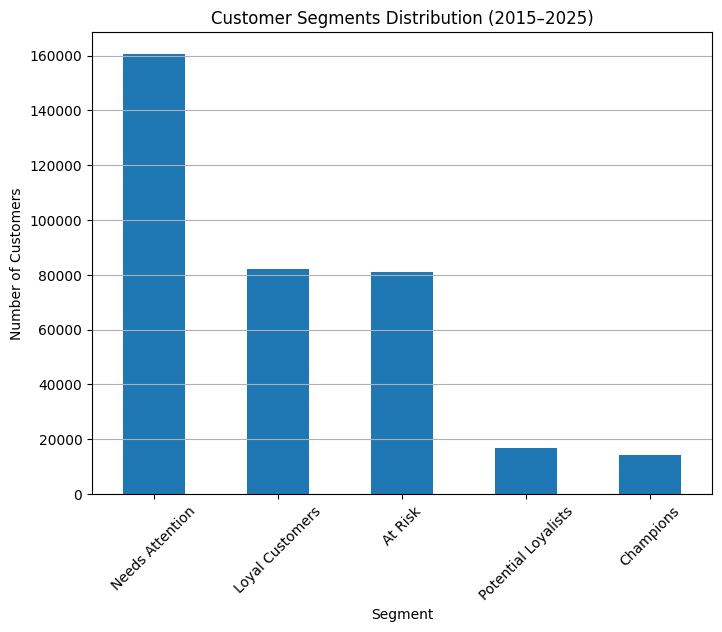

In [20]:

plt.figure(figsize=(8, 6))
segment_summary['Customers'].plot(kind='bar')
plt.title('Customer Segments Distribution (2015–2025)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show() 

Question 4
Visualize the evolution of payment methods from 2015-2025. Show the rise of UPI, decline of COD, and create stacked area charts to demonstrate market share changes over time.


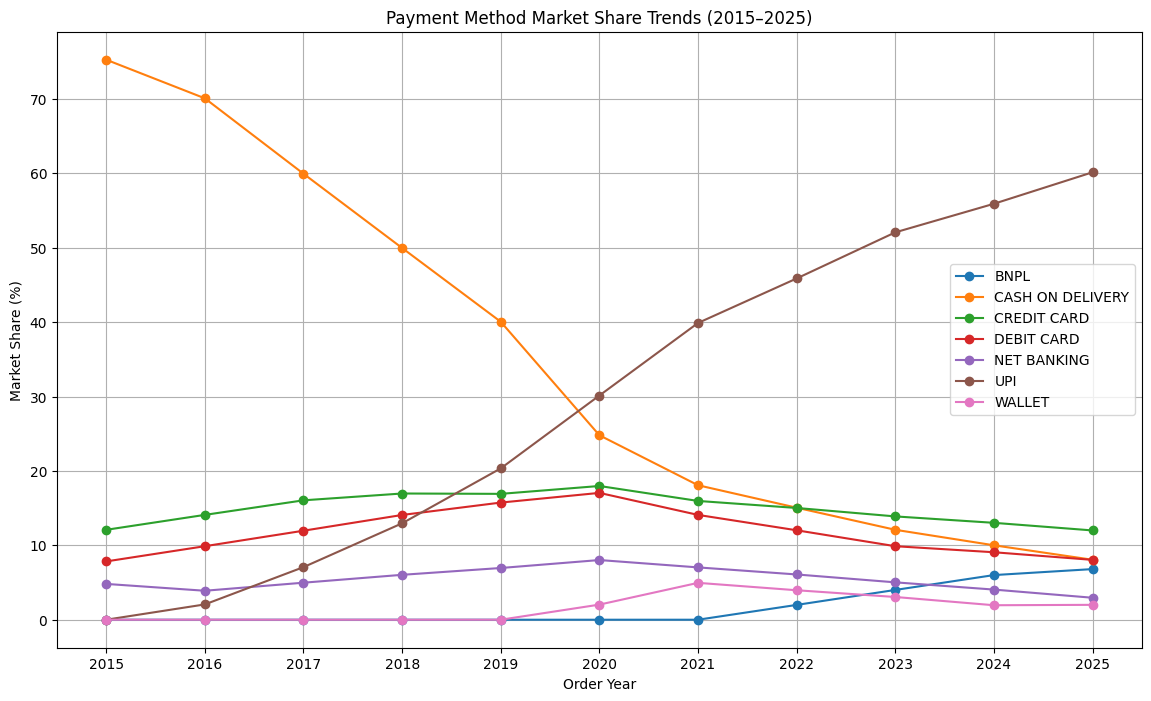

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

years = [2015, 2016, 2017, 2018,2019,2020,2021,2022,2023,2024,2025]
dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    dfs.append(pd.read_csv(path))

df = pd.concat(dfs, ignore_index=True)

df['order_year'] = pd.to_numeric(df['order_year'], errors='coerce')

df = df[(df['order_year'] >= 2015) & (df['order_year'] <= 2025)]

df = df.dropna(subset=['order_year', 'payment_method'])

df['payment_method'] = df['payment_method'].str.upper().str.strip()

payment_yearly = (
    df.groupby(['order_year', 'payment_method'])
      .size()
      .reset_index(name='transactions')
)

total_yearly = payment_yearly.groupby('order_year')['transactions'].transform('sum')
payment_yearly['market_share'] = (
    payment_yearly['transactions'] / total_yearly * 100
)

payment_pivot = payment_yearly.pivot(
    index='order_year',
    columns='payment_method',
    values='market_share'
).fillna(0)

plt.figure(figsize=(14, 8))

for method in payment_pivot.columns:
    plt.plot(
        payment_pivot.index,
        payment_pivot[method],
        marker='o',
        label=method
    )

plt.title('Payment Method Market Share Trends (2015–2025)')
plt.xlabel('Order Year')
plt.ylabel('Market Share (%)')
plt.xticks(range(2015, 2026))
plt.legend()
plt.grid(True)

plt.show()


Question 5
Perform category-wise performance analysis. Create treemaps, bar charts, and pie charts showing revenue contribution, growth rates, and market share for each product category.


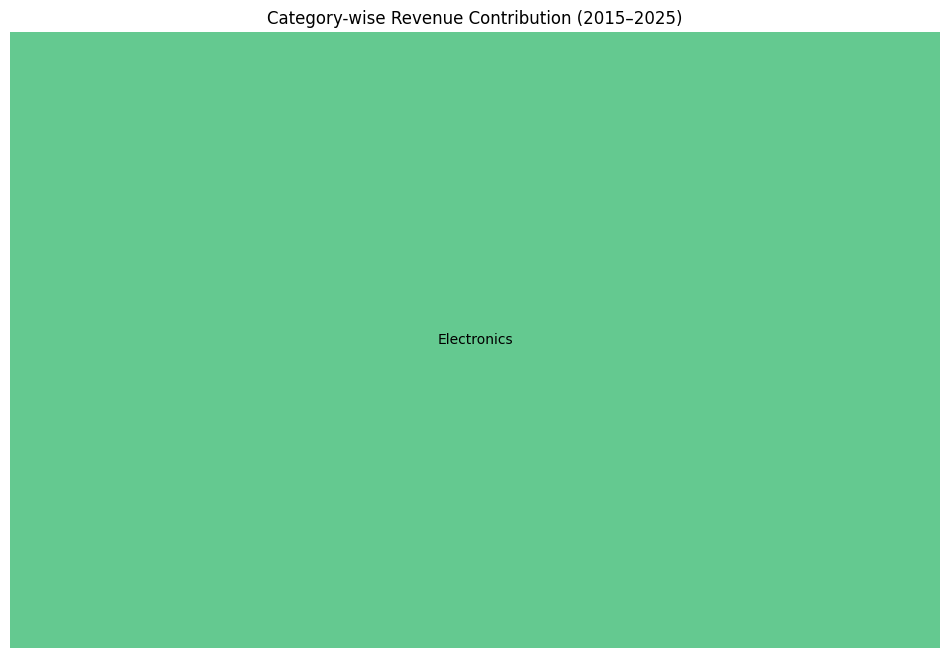

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

years = range(2015, 2026)
use_cols = ['order_year', 'category', 'final_amount_inr']

dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    df_y = pd.read_csv(
        path,
        usecols=use_cols,
        low_memory=False
    )
    dfs.append(df_y)

df = pd.concat(dfs, ignore_index=True)


df['order_year'] = pd.to_numeric(df['order_year'], errors='coerce')
df['final_amount_inr'] = pd.to_numeric(df['final_amount_inr'], errors='coerce')


df = df[(df['order_year'] >= 2015) & (df['order_year'] <= 2025)]

df = df.dropna(subset=['category', 'order_year', 'final_amount_inr'])


df['category'] = df['category'].str.title().str.strip()

category_revenue = (
    df.groupby('category')['final_amount_inr']
      .sum()
      .reset_index()
      .sort_values('final_amount_inr', ascending=False)
)


total_revenue = category_revenue['final_amount_inr'].sum()
category_revenue['market_share_pct'] = (
    category_revenue['final_amount_inr'] / total_revenue * 100
)

category_yearly = (
    df.groupby(['order_year', 'category'])['final_amount_inr']
      .sum()
      .reset_index()
)

category_yearly['yoy_growth_pct'] = (
    category_yearly
    .groupby('category')['final_amount_inr']
    .pct_change() * 100
)


plt.figure(figsize=(12, 8))
squarify.plot(
    sizes=category_revenue['final_amount_inr'],
    label=category_revenue['category'],
    alpha=0.8
)
plt.title('Category-wise Revenue Contribution (2015–2025)')
plt.axis('off')
plt.show()


In [2]:
import sys
!{sys.executable} -m pip install squarify


  Using cached squarify-0.4.4-py3-none-any.whl.metadata (600 bytes)
Using cached squarify-0.4.4-py3-none-any.whl (4.1 kB)



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


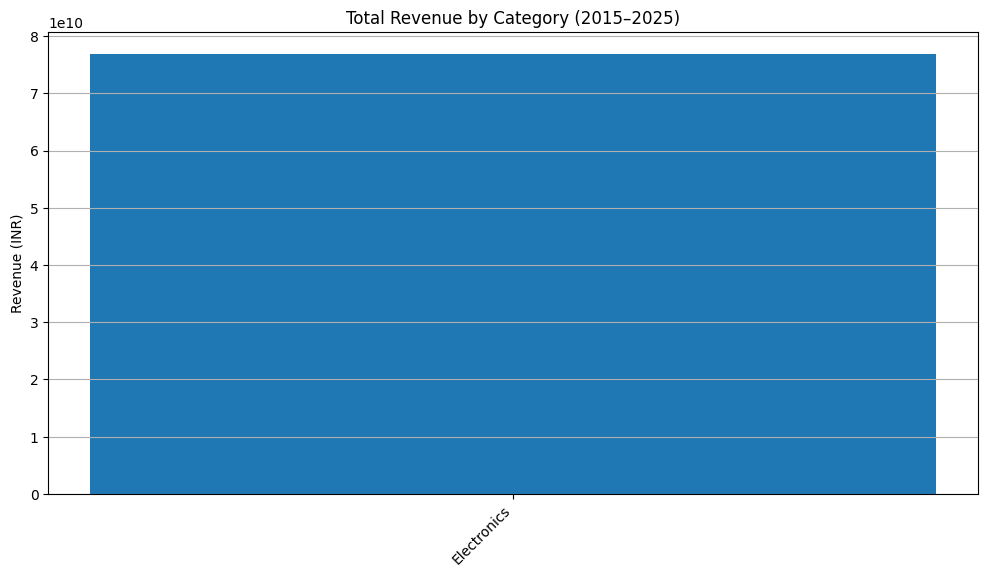

In [5]:

plt.figure(figsize=(12, 6))
plt.bar(
    category_revenue['category'],
    category_revenue['final_amount_inr']
)
plt.xticks(rotation=45, ha='right')
plt.title('Total Revenue by Category (2015–2025)')
plt.ylabel('Revenue (INR)')
plt.grid(axis='y')
plt.show()


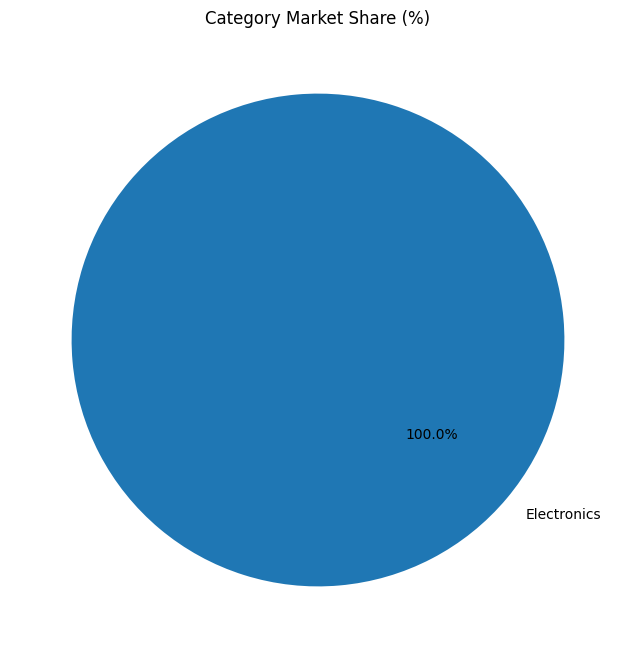

In [6]:
plt.figure(figsize=(8, 8))
plt.pie(
    category_revenue['market_share_pct'],
    labels=category_revenue['category'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Category Market Share (%)')
plt.show()


Question 6
Analyze Prime membership impact on customer behavior. Compare average order values, order frequency, and category preferences between Prime and non-Prime customers using multiple visualization types.


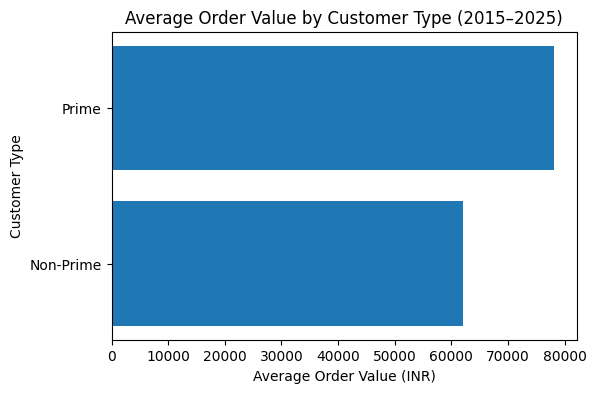

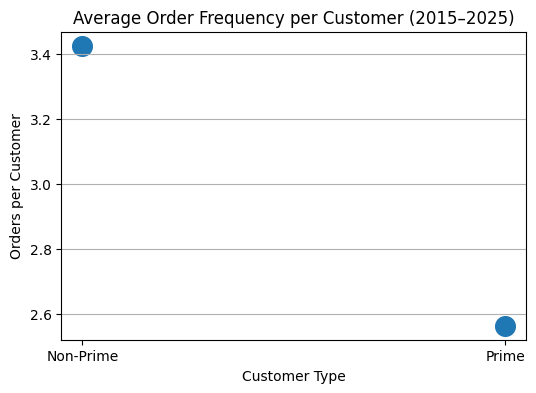

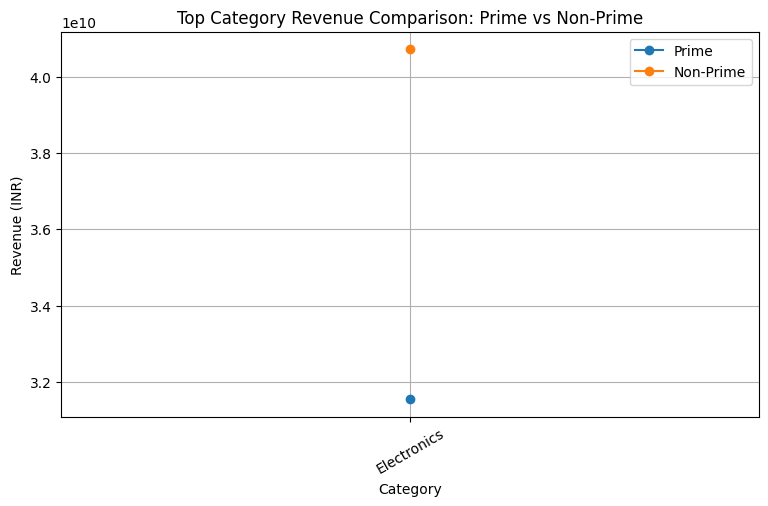

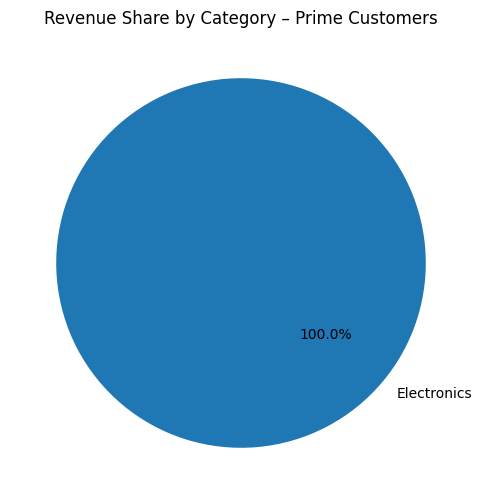

<Figure size 600x500 with 0 Axes>

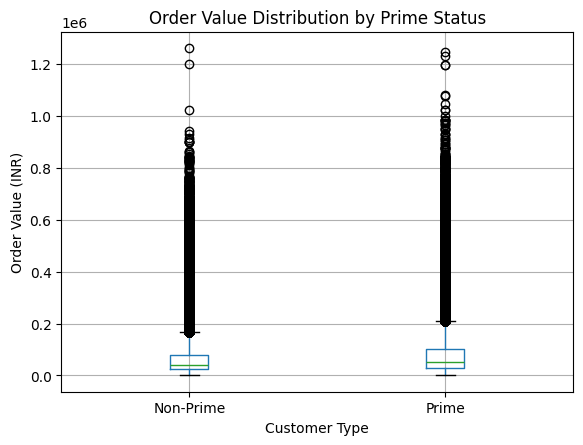

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

years = range(2015, 2026)

use_cols = [
    'customer_id',
    'order_year',
    'final_amount_inr',
    'category',
    'is_prime_member'
]

dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    df_y = pd.read_csv(path, usecols=use_cols, low_memory=False)
    dfs.append(df_y)

df = pd.concat(dfs, ignore_index=True)


df['order_year'] = pd.to_numeric(df['order_year'], errors='coerce')
df['final_amount_inr'] = pd.to_numeric(df['final_amount_inr'], errors='coerce')

df = df.dropna(subset=[
    'customer_id',
    'order_year',
    'final_amount_inr',
    'is_prime_member'
])

df = df[(df['order_year'] >= 2015) & (df['order_year'] <= 2025)]

df['prime_status'] = df['is_prime_member'].map({
    True: 'Prime',
    False: 'Non-Prime'
})

df['category'] = df['category'].astype(str).str.strip().str.title()

aov = (
    df.groupby('prime_status')['final_amount_inr']
      .mean()
      .reset_index()
)

plt.figure(figsize=(6,4))
plt.barh(aov['prime_status'], aov['final_amount_inr'])
plt.title('Average Order Value by Customer Type (2015–2025)')
plt.xlabel('Average Order Value (INR)')
plt.ylabel('Customer Type')
plt.show()


frequency = (
    df.groupby(['prime_status', 'customer_id'])
      .size()
      .reset_index(name='order_count')
)

freq_summary = (
    frequency.groupby('prime_status')['order_count']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))
plt.scatter(
    freq_summary['prime_status'],
    freq_summary['order_count'],
    s=200
)
plt.title('Average Order Frequency per Customer (2015–2025)')
plt.ylabel('Orders per Customer')
plt.xlabel('Customer Type')
plt.grid(True, axis='y')
plt.show()


category_pref = (
    df.groupby(['prime_status', 'category'])['final_amount_inr']
      .sum()
      .reset_index()
)


top_categories = (
    category_pref.groupby('category')['final_amount_inr']
    .sum()
    .nlargest(5)
    .index
)

filtered = category_pref[category_pref['category'].isin(top_categories)]

plt.figure(figsize=(9,5))

for status in ['Prime', 'Non-Prime']:
    subset = filtered[filtered['prime_status'] == status]
    plt.plot(
        subset['category'],
        subset['final_amount_inr'],
        marker='o',
        label=status
    )

plt.title('Top Category Revenue Comparison: Prime vs Non-Prime')
plt.ylabel('Revenue (INR)')
plt.xlabel('Category')
plt.legend()
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

top_prime = (
    category_pref[category_pref['prime_status'] == 'Prime']
    .nlargest(5, 'final_amount_inr')
)

plt.figure(figsize=(6,6))
plt.pie(
    top_prime['final_amount_inr'],
    labels=top_prime['category'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Revenue Share by Category – Prime Customers')
plt.show()

plt.figure(figsize=(6,5))
df.boxplot(
    column='final_amount_inr',
    by='prime_status'
)

plt.title('Order Value Distribution by Prime Status')
plt.suptitle('')
plt.ylabel('Order Value (INR)')
plt.xlabel('Customer Type')
plt.show()


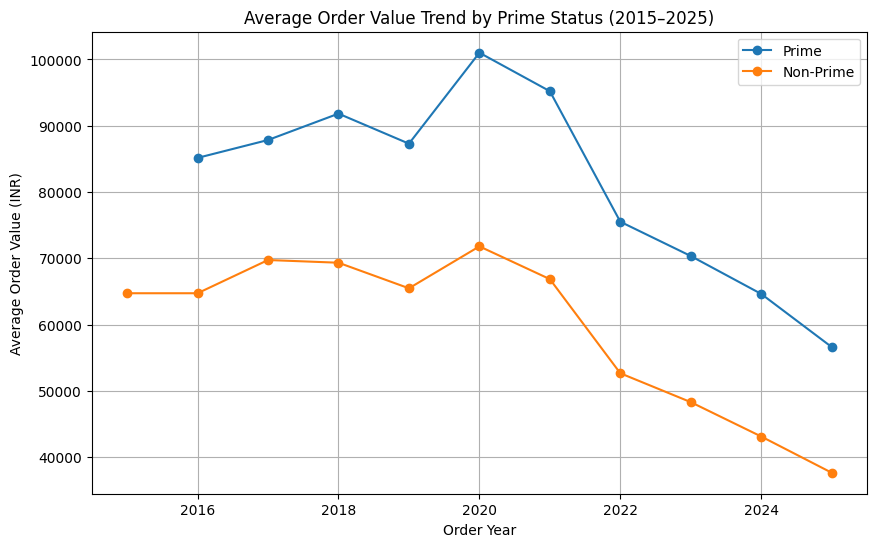

In [20]:
aov_yearly = (
    df.groupby(['order_year', 'prime_status'])['final_amount_inr']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

for segment in ['Prime', 'Non-Prime']:
    subset = aov_yearly[aov_yearly['prime_status'] == segment]
    plt.plot(
        subset['order_year'],
        subset['final_amount_inr'],
        marker='o',
        label=segment
    )

plt.title('Average Order Value Trend by Prime Status (2015–2025)')
plt.xlabel('Order Year')
plt.ylabel('Average Order Value (INR)')
plt.legend()
plt.grid(True)
plt.show()


Question 7
Create geographic analysis of sales performance across Indian cities and states. Build choropleth maps and bar charts showing revenue density and growth patterns by tier (Metro/Tier1/Tier2/Rural).


Available columns:
 Index(['transaction_id', 'order_date', 'customer_id', 'product_id',
       'product_name', 'category', 'subcategory', 'brand',
       'original_price_inr', 'discount_percent', 'discounted_price_inr',
       'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr',
       'customer_city', 'customer_state', 'customer_tier',
       'customer_spending_tier', 'customer_age_group', 'payment_method',
       'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale',
       'festival_name', 'customer_rating', 'return_status', 'order_month',
       'order_year', 'order_quarter', 'product_weight_kg', 'is_prime_eligible',
       'product_rating'],
      dtype='object')


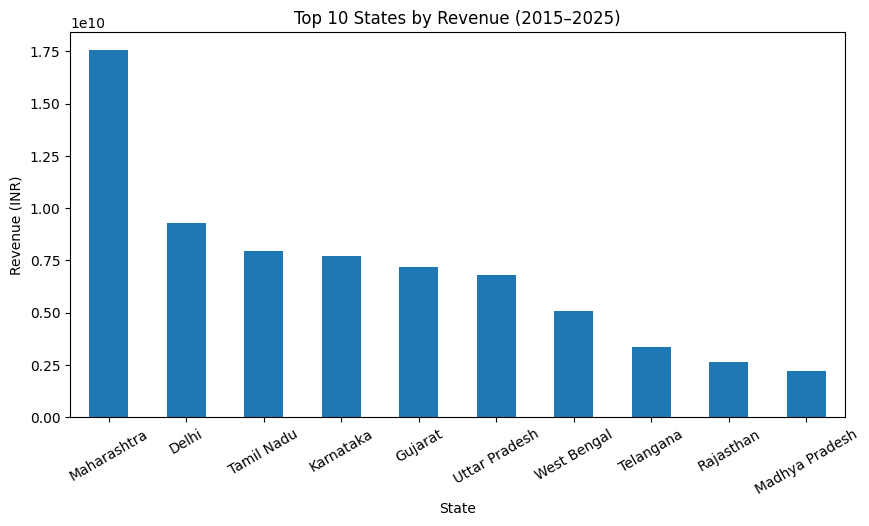

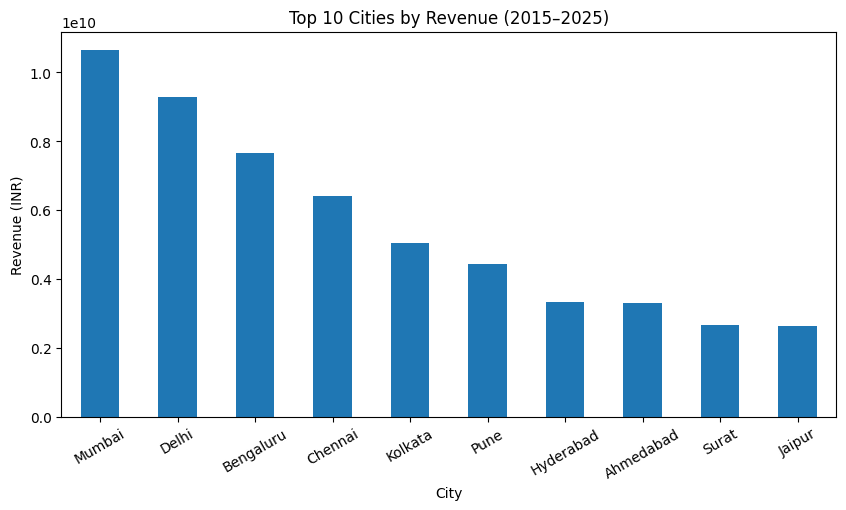

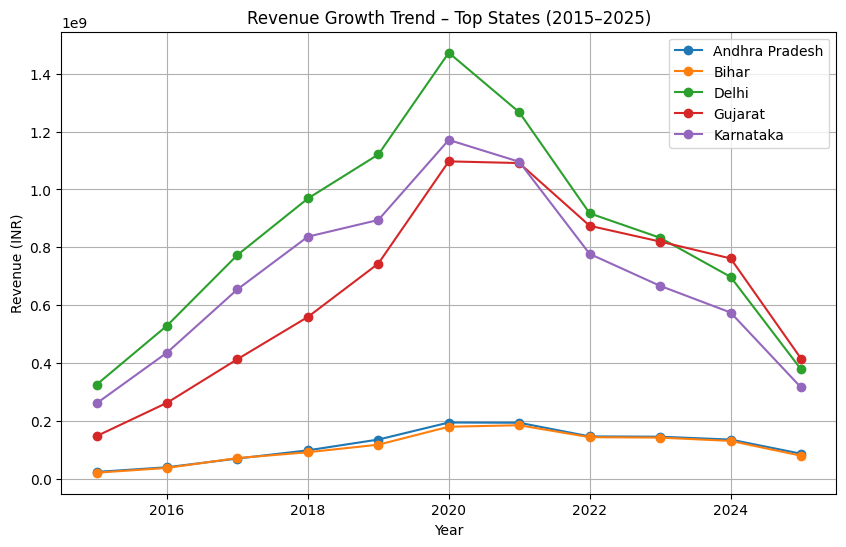

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
years = range(2015, 2026)
dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    df_y = pd.read_csv(path, low_memory=False)
    dfs.append(df_y)

df = pd.concat(dfs, ignore_index=True)

df['order_year'] = pd.to_numeric(df.get('order_year'), errors='coerce')
df['final_amount_inr'] = pd.to_numeric(df.get('final_amount_inr'), errors='coerce')

df = df.dropna(subset=['order_year', 'final_amount_inr'])
df = df[(df['order_year'] >= 2015) & (df['order_year'] <= 2025)]


if 'customer_state' in df.columns:

    df['state'] = df['customer_state'].astype(str).str.title().str.strip()

    state_revenue = (
        df.groupby('state')['final_amount_inr']
          .sum()
          .sort_values(ascending=False)
          .head(10)
    )

    plt.figure(figsize=(10,5))
    state_revenue.plot(kind='bar')
    plt.title('Top 10 States by Revenue (2015–2025)')
    plt.ylabel('Revenue (INR)')
    plt.xlabel('State')
    plt.xticks(rotation=30)
    plt.show()

else:
    print("⚠️ 'state' column not found – skipping state analysis")

if 'customer_city' in df.columns:

    df['city'] = df['customer_city'].astype(str).str.title().str.strip()

    city_revenue = (
        df.groupby('city')['final_amount_inr']
          .sum()
          .sort_values(ascending=False)
          .head(10)
    )

    plt.figure(figsize=(10,5))
    city_revenue.plot(kind='bar')
    plt.title('Top 10 Cities by Revenue (2015–2025)')
    plt.ylabel('Revenue (INR)')
    plt.xlabel('City')
    plt.xticks(rotation=30)
    plt.show()

else:
    print("⚠️ 'city' column not found – skipping city analysis")

if 'state' in df.columns:

    yearly_state = (
        df.groupby(['order_year', 'state'])['final_amount_inr']
          .sum()
          .reset_index()
    )

    plt.figure(figsize=(10,6))

    for state in yearly_state['state'].value_counts().head(5).index:
        subset = yearly_state[yearly_state['state'] == state]
        plt.plot(
            subset['order_year'],
            subset['final_amount_inr'],
            marker='o',
            label=state
        )

    plt.title('Revenue Growth Trend – Top States (2015–2025)')
    plt.xlabel('Year')
    plt.ylabel('Revenue (INR)')
    plt.legend()
    plt.grid(True)
    plt.show()


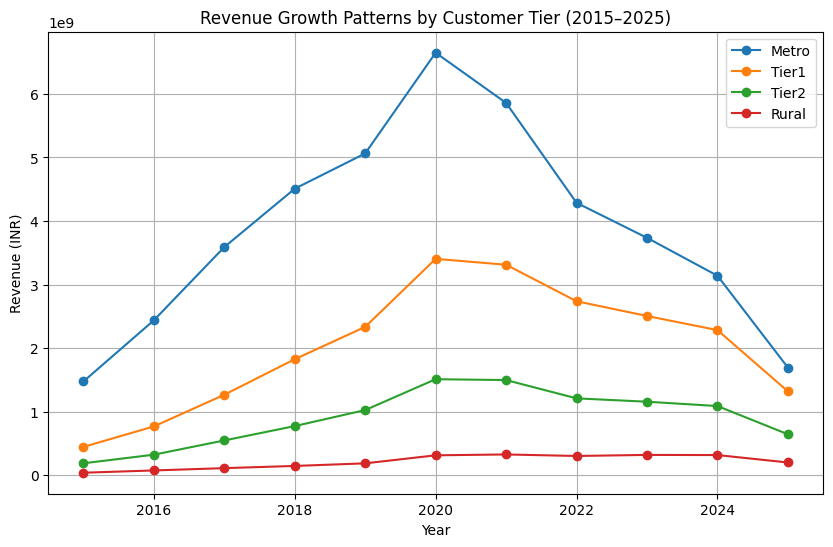

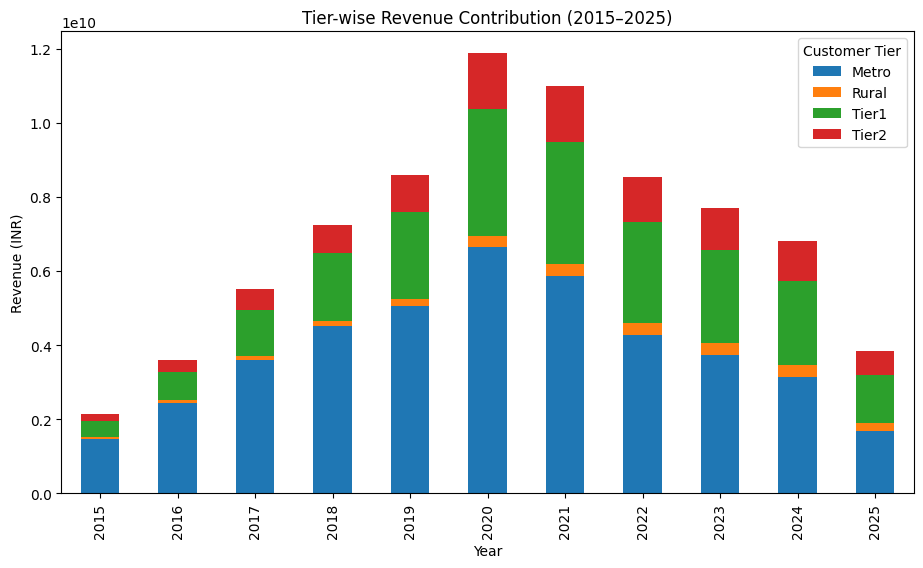

In [25]:
df['customer_tier'] = (
    df['customer_tier']
    .str.strip()
    .str.title()
)

tier_yearly = (
    df.groupby(['order_year', 'customer_tier'])['final_amount_inr']
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,6))

for tier in ['Metro', 'Tier1', 'Tier2', 'Rural']:
    subset = tier_yearly[tier_yearly['customer_tier'] == tier]
    plt.plot(
        subset['order_year'],
        subset['final_amount_inr'],
        marker='o',
        label=tier
    )

plt.title('Revenue Growth Patterns by Customer Tier (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Revenue (INR)')
plt.legend()
plt.grid(True)
plt.show()


tier_pivot = tier_yearly.pivot(
    index='order_year',
    columns='customer_tier',
    values='final_amount_inr'
).fillna(0)

tier_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(11,6)
)

plt.title('Tier-wise Revenue Contribution (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Revenue (INR)')
plt.legend(title='Customer Tier')
plt.show()


growth_summary = (
    tier_yearly
    .groupby('customer_tier')
    .agg(
        Total_Revenue=('final_amount_inr', 'sum'),
        Avg_Annual_Revenue=('final_amount_inr', 'mean')
    )
    .sort_values('Total_Revenue', ascending=False)
)


Question 8
Study festival sales impact using before/during/after analysis. Visualize revenue spikes during Diwali, Prime Day, and other festivals with detailed time series analysis.


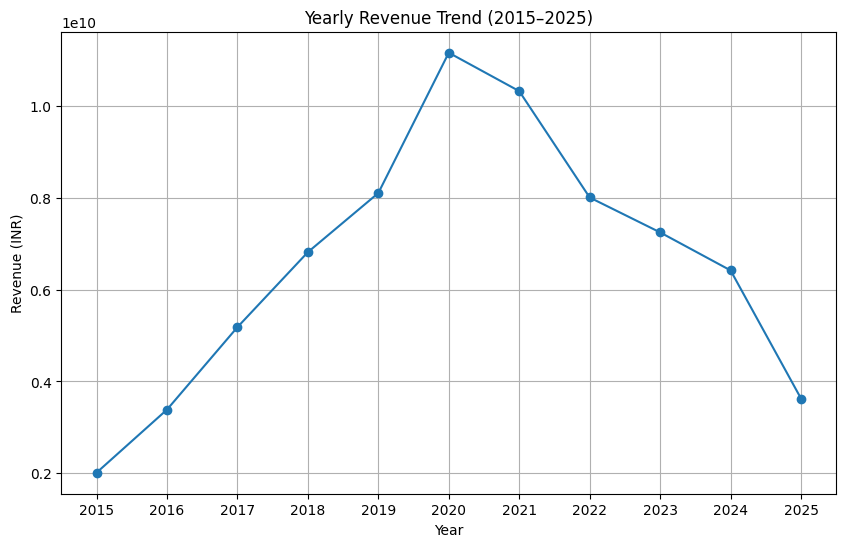

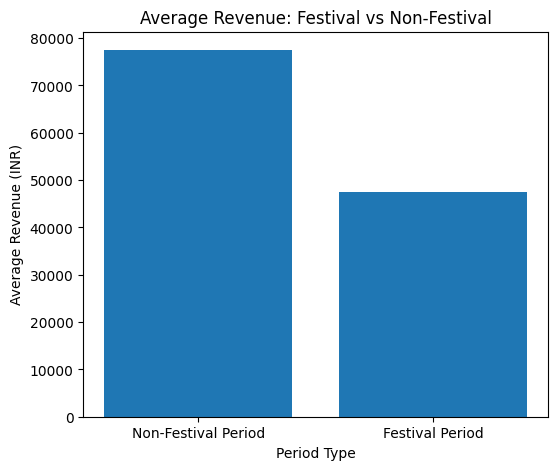

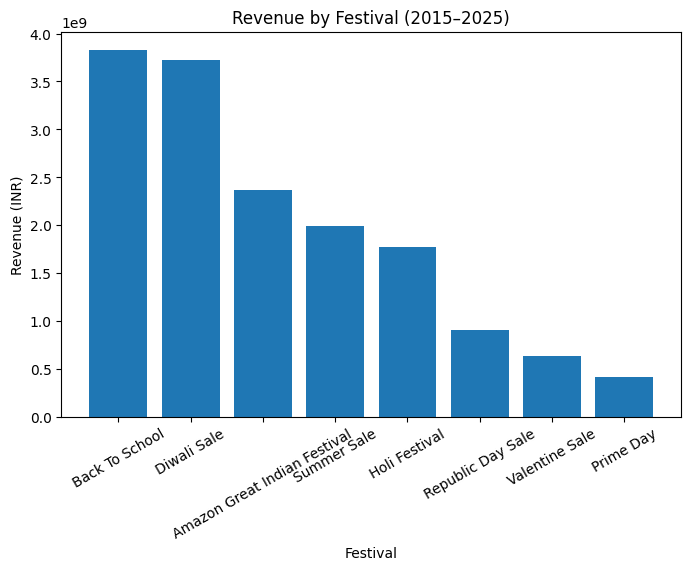

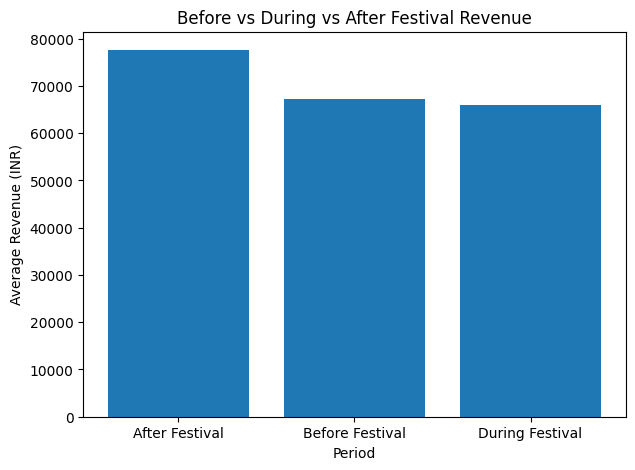

In [27]:
import pandas as pd
import matplotlib.pyplot as plt


years = range(2015, 2026)
dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    dfs.append(pd.read_csv(path, low_memory=False))

df = pd.concat(dfs, ignore_index=True)

df['order_year'] = pd.to_numeric(df['order_year'], errors='coerce')
df['order_month'] = pd.to_numeric(df['order_month'], errors='coerce')
df['final_amount_inr'] = pd.to_numeric(df['final_amount_inr'], errors='coerce')

df = df.dropna(subset=[
    'order_year',
    'order_month',
    'final_amount_inr',
    'is_festival_sale'
])

df = df[(df['order_year'] >= 2015) & (df['order_year'] <= 2025)]

df['festival_name'] = (
    df['festival_name']
    .fillna('Non-Festival')
    .str.title()
    .str.strip()
)


yearly_revenue = (
    df.groupby('order_year')['final_amount_inr']
      .sum()
      .reset_index()
      .sort_values('order_year')
)

plt.figure(figsize=(10,6))
plt.plot(
    yearly_revenue['order_year'],
    yearly_revenue['final_amount_inr'],
    marker='o'
)

plt.title('Yearly Revenue Trend (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Revenue (INR)')
plt.xticks(yearly_revenue['order_year'])
plt.grid(True)
plt.show()


festival_comparison = (
    df.groupby('is_festival_sale')['final_amount_inr']
      .mean()
      .reset_index()
)

festival_comparison['is_festival_sale'] = festival_comparison['is_festival_sale'].map({
    True: 'Festival Period',
    False: 'Non-Festival Period'
})

plt.figure(figsize=(6,5))
plt.bar(
    festival_comparison['is_festival_sale'],
    festival_comparison['final_amount_inr']
)

plt.title('Average Revenue: Festival vs Non-Festival')
plt.ylabel('Average Revenue (INR)')
plt.xlabel('Period Type')
plt.show()

festival_revenue = (
    df[df['is_festival_sale'] == True]
    .groupby('festival_name')['final_amount_inr']
    .sum()
    .reset_index()
    .sort_values('final_amount_inr', ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(
    festival_revenue['festival_name'],
    festival_revenue['final_amount_inr']
)

plt.title('Revenue by Festival (2015–2025)')
plt.ylabel('Revenue (INR)')
plt.xlabel('Festival')
plt.xticks(rotation=30)
plt.show()

df['period'] = 'Normal'

festival_months = (
    df[df['is_festival_sale'] == True]
    [['order_year', 'order_month']]
    .drop_duplicates()
)

for _, row in festival_months.iterrows():
    y, m = row['order_year'], row['order_month']

    df.loc[
        (df['order_year'] == y) &
        (df['order_month'] == m),
        'period'
    ] = 'During Festival'

    df.loc[
        (df['order_year'] == y) &
        (df['order_month'] == m - 1),
        'period'
    ] = 'Before Festival'

    df.loc[
        (df['order_year'] == y) &
        (df['order_month'] == m + 1),
        'period'
    ] = 'After Festival'

period_revenue = (
    df.groupby('period')['final_amount_inr']
      .mean()
      .reset_index()
)

plt.figure(figsize=(7,5))
plt.bar(
    period_revenue['period'],
    period_revenue['final_amount_inr']
)

plt.title('Before vs During vs After Festival Revenue')
plt.ylabel('Average Revenue (INR)')
plt.xlabel('Period')
plt.show()


Question 9
Analyze customer age group behavior and preferences. Create demographic analysis with category preferences, spending patterns, and shopping frequency across different age segments.

C:\Users\hp\AppData\Local\Temp\ipykernel_13620\3536566080.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer_age_group')['final_amount_inr']


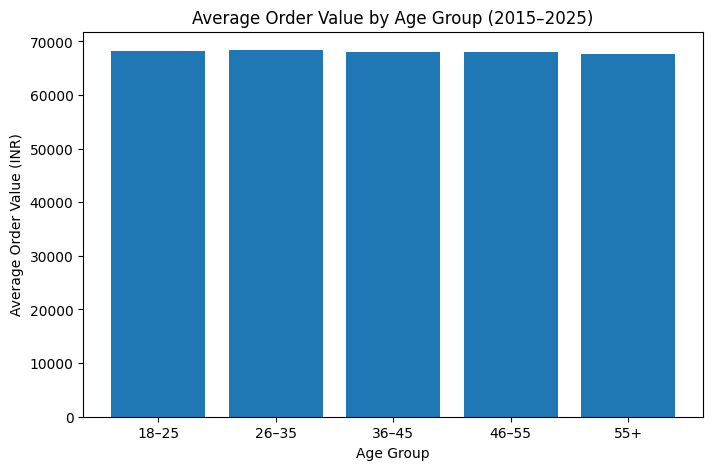

C:\Users\hp\AppData\Local\Temp\ipykernel_13620\3536566080.py:89: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['customer_age_group', 'customer_id'])
C:\Users\hp\AppData\Local\Temp\ipykernel_13620\3536566080.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order_freq.groupby('customer_age_group')['order_count']


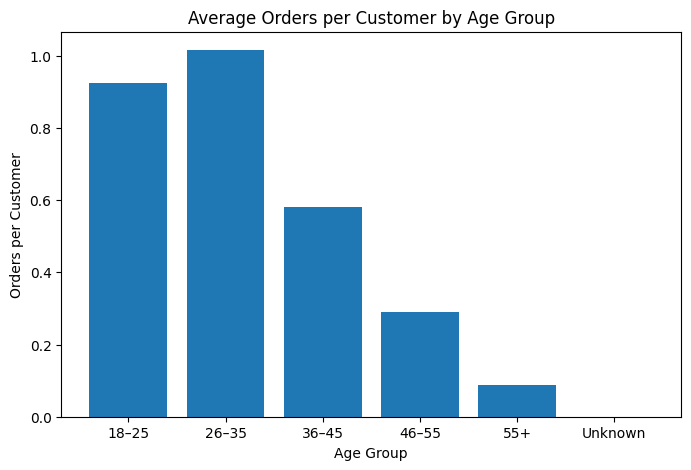

C:\Users\hp\AppData\Local\Temp\ipykernel_13620\3536566080.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['customer_age_group', 'category'])['final_amount_inr']
C:\Users\hp\AppData\Local\Temp\ipykernel_13620\3536566080.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('customer_age_group')


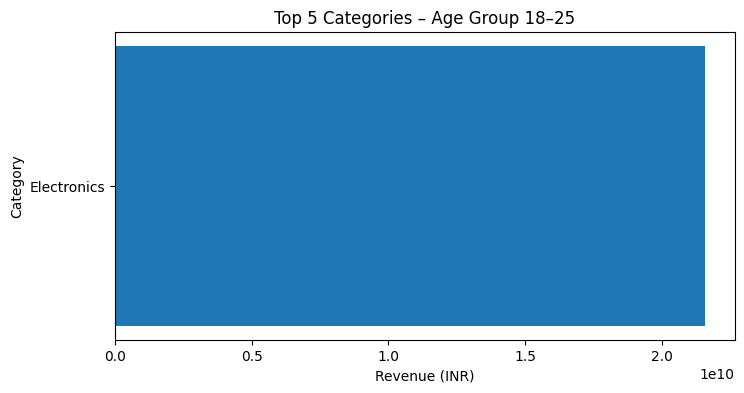

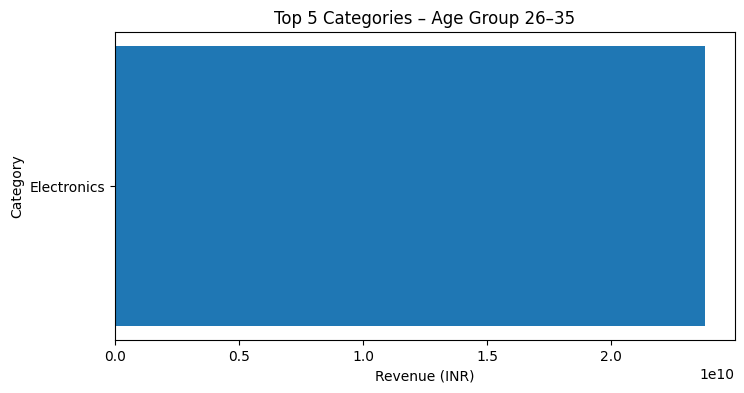

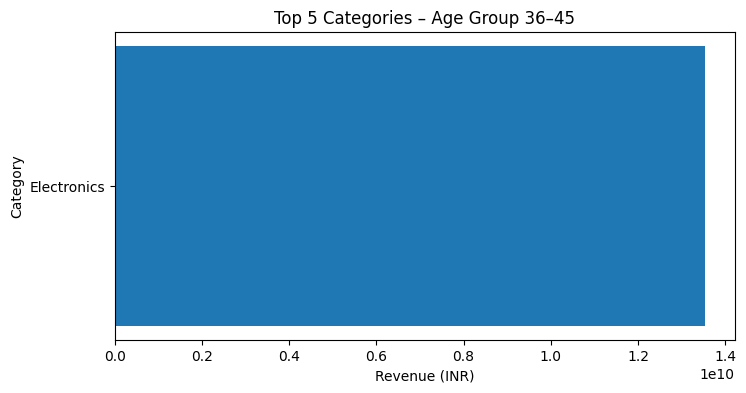

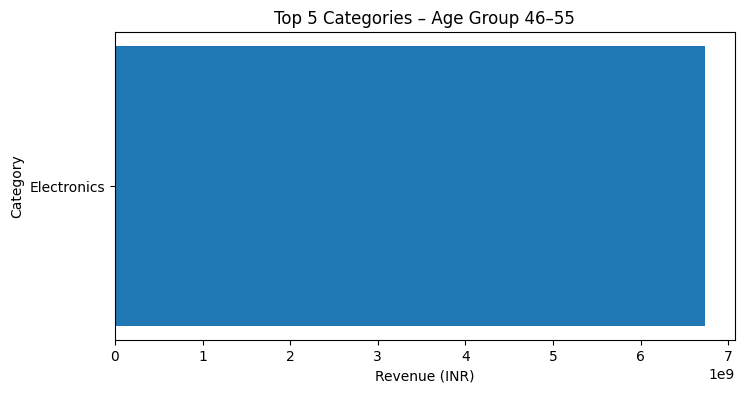

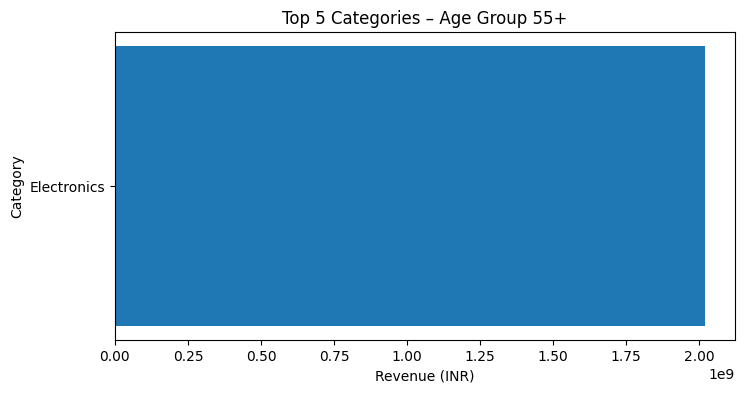

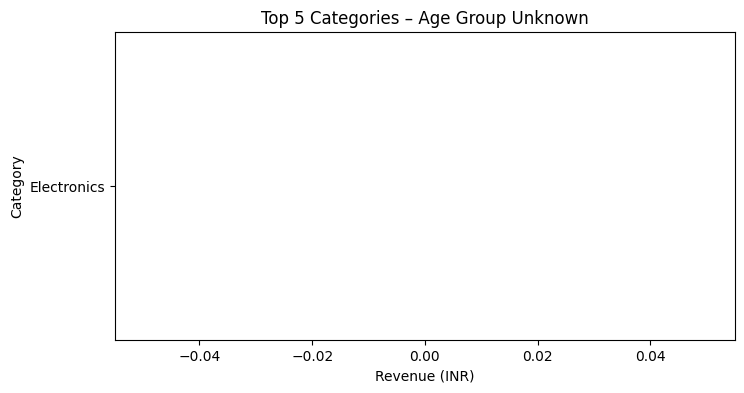

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# 1. LOAD DATA
# -----------------------------------

years = range(2015, 2026)

use_cols = [
    'customer_id',
    'order_year',
    'final_amount_inr',
    'category',
    'customer_age_group'
]

dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    df_y = pd.read_csv(path, usecols=use_cols, low_memory=False)
    dfs.append(df_y)

df = pd.concat(dfs, ignore_index=True)

# -----------------------------------
# 2. CLEANING
# -----------------------------------

df['order_year'] = pd.to_numeric(df['order_year'], errors='coerce')
df['final_amount_inr'] = pd.to_numeric(df['final_amount_inr'], errors='coerce')

df = df.dropna(subset=[
    'customer_id',
    'order_year',
    'final_amount_inr',
    'customer_age_group'
])

df = df[(df['order_year'] >= 2015) & (df['order_year'] <= 2025)]

# ---- Clean Age Group (single standardized value)
df['customer_age_group'] = (
    df['customer_age_group']
      .astype(str)
      .str.strip()
      .replace({
          'nan': 'Unknown',
          '18-25': '18–25',
          '26-35': '26–35',
          '36-45': '36–45',
          '46-55': '46–55',
          '55+': '55+'
      })
)

age_order = ['18–25', '26–35', '36–45', '46–55', '55+', 'Unknown']
df['customer_age_group'] = pd.Categorical(
    df['customer_age_group'],
    categories=age_order,
    ordered=True
)

df['category'] = df['category'].str.strip().str.title()

# -----------------------------------
# 3. SPENDING PATTERN – AOV BY AGE GROUP
# -----------------------------------

aov_age = (
    df.groupby('customer_age_group')['final_amount_inr']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.bar(aov_age['customer_age_group'], aov_age['final_amount_inr'])
plt.title('Average Order Value by Age Group (2015–2025)')
plt.ylabel('Average Order Value (INR)')
plt.xlabel('Age Group')
plt.show()

# -----------------------------------
# 4. SHOPPING FREQUENCY BY AGE GROUP
# -----------------------------------

order_freq = (
    df.groupby(['customer_age_group', 'customer_id'])
      .size()
      .reset_index(name='order_count')
)

freq_summary = (
    order_freq.groupby('customer_age_group')['order_count']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.bar(freq_summary['customer_age_group'], freq_summary['order_count'])
plt.title('Average Orders per Customer by Age Group')
plt.ylabel('Orders per Customer')
plt.xlabel('Age Group')
plt.show()

# -----------------------------------
# 5. CATEGORY PREFERENCE BY AGE GROUP
# -----------------------------------

category_pref = (
    df.groupby(['customer_age_group', 'category'])['final_amount_inr']
      .sum()
      .reset_index()
)

# Take top 5 categories per age group
top_categories = (
    category_pref
    .sort_values(['customer_age_group', 'final_amount_inr'], ascending=[True, False])
    .groupby('customer_age_group')
    .head(5)
)

# Plot per age group (horizontal bar for clarity)
for age in age_order:
    subset = top_categories[top_categories['customer_age_group'] == age]
    if subset.empty:
        continue

    plt.figure(figsize=(8,4))
    plt.barh(subset['category'], subset['final_amount_inr'])
    plt.title(f'Top 5 Categories – Age Group {age}')
    plt.xlabel('Revenue (INR)')
    plt.ylabel('Category')
    plt.show()


Question 10
Build price vs demand analysis using scatter plots and correlation matrices. Analyze how pricing strategies affect sales volumes across different categories and customer segments.


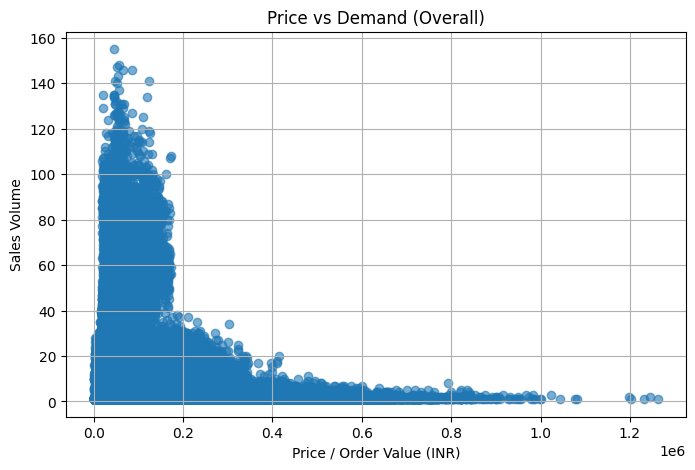

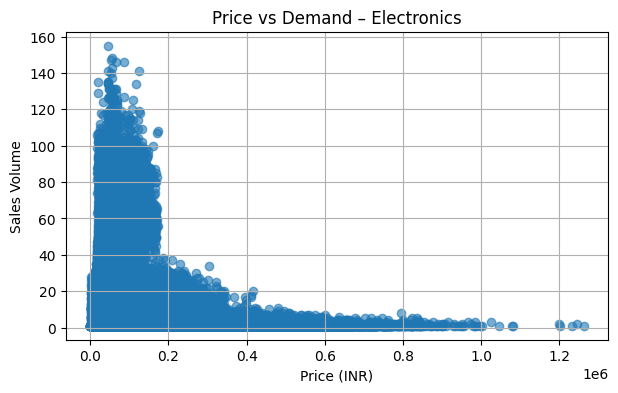

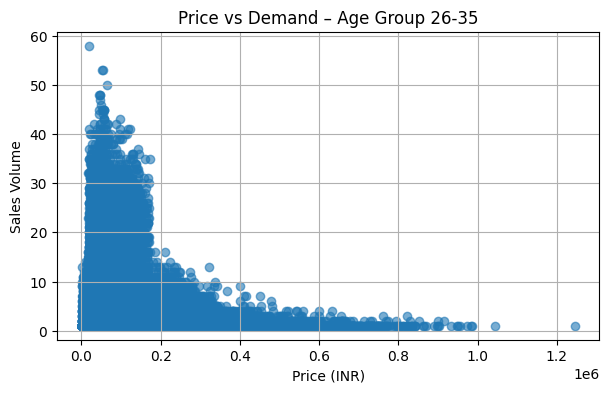

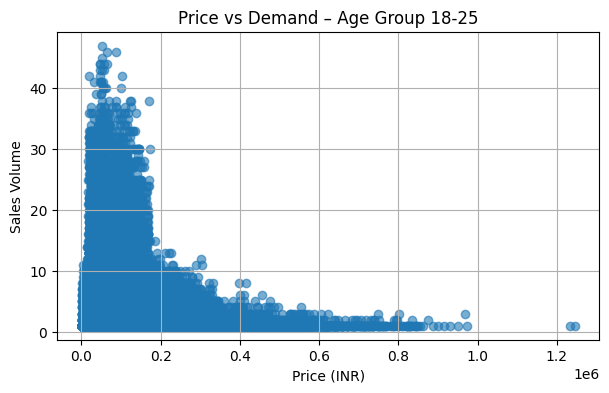

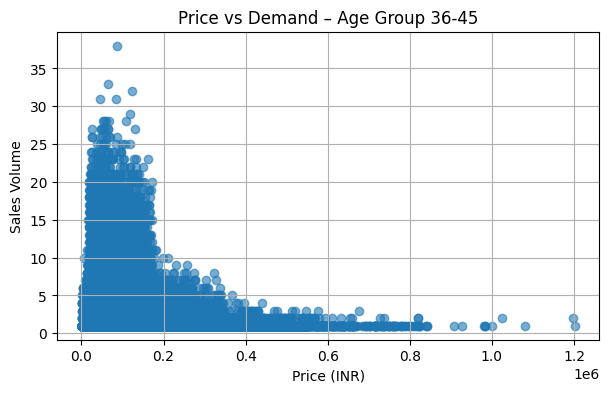

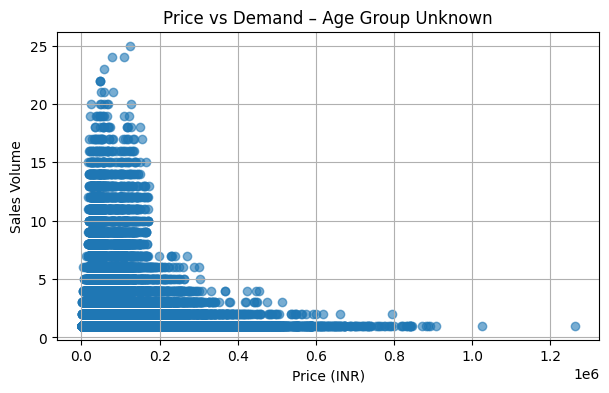

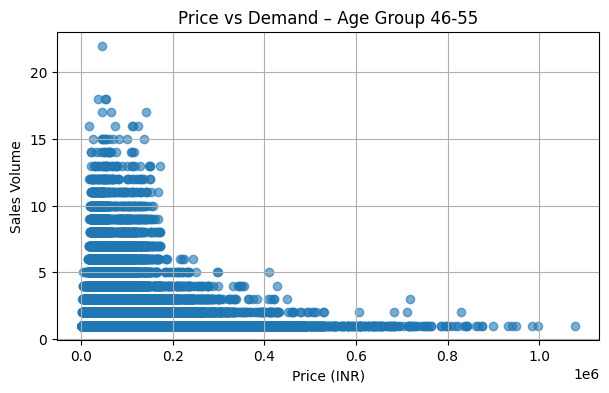

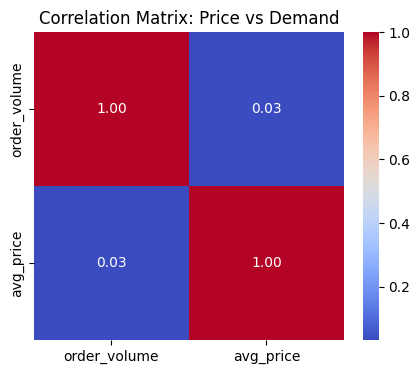

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# 1. LOAD DATA (2015–2025)
# -----------------------------------

years = range(2015, 2026)

use_cols = [
    'customer_id',
    'order_year',
    'final_amount_inr',
    'category',
    'customer_age_group'
]

dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    df_y = pd.read_csv(path, usecols=use_cols, low_memory=False)
    dfs.append(df_y)

df = pd.concat(dfs, ignore_index=True)

# -----------------------------------
# 2. DATA CLEANING
# -----------------------------------

df['order_year'] = pd.to_numeric(df['order_year'], errors='coerce')
df['final_amount_inr'] = pd.to_numeric(df['final_amount_inr'], errors='coerce')

df = df.dropna(subset=[
    'customer_id',
    'order_year',
    'final_amount_inr',
    'category'
])

df = df[(df['order_year'] >= 2015) & (df['order_year'] <= 2025)]

df['category'] = df['category'].str.strip().str.title()

df['customer_age_group'] = (
    df['customer_age_group']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)

# -----------------------------------
# 3. PRICE vs DEMAND (OVERALL)
# Demand = Order Volume
# -----------------------------------

price_demand = (
    df.groupby('final_amount_inr')
      .size()
      .reset_index(name='order_volume')
)

plt.figure(figsize=(8,5))
plt.scatter(
    price_demand['final_amount_inr'],
    price_demand['order_volume'],
    alpha=0.6
)
plt.title('Price vs Demand (Overall)')
plt.xlabel('Price / Order Value (INR)')
plt.ylabel('Sales Volume')
plt.grid(True)
plt.show()

# -----------------------------------
# 4. PRICE vs DEMAND BY CATEGORY
# -----------------------------------

category_pd = (
    df.groupby(['category', 'final_amount_inr'])
      .size()
      .reset_index(name='order_volume')
)

top_categories = df['category'].value_counts().head(5).index

for cat in top_categories:
    subset = category_pd[category_pd['category'] == cat]

    plt.figure(figsize=(7,4))
    plt.scatter(
        subset['final_amount_inr'],
        subset['order_volume'],
        alpha=0.6
    )
    plt.title(f'Price vs Demand – {cat}')
    plt.xlabel('Price (INR)')
    plt.ylabel('Sales Volume')
    plt.grid(True)
    plt.show()

# -----------------------------------
# 5. PRICE vs DEMAND BY CUSTOMER AGE GROUP
# -----------------------------------

age_pd = (
    df.groupby(['customer_age_group', 'final_amount_inr'])
      .size()
      .reset_index(name='order_volume')
)

top_age_groups = df['customer_age_group'].value_counts().head(5).index

for age in top_age_groups:
    subset = age_pd[age_pd['customer_age_group'] == age]

    plt.figure(figsize=(7,4))
    plt.scatter(
        subset['final_amount_inr'],
        subset['order_volume'],
        alpha=0.6
    )
    plt.title(f'Price vs Demand – Age Group {age}')
    plt.xlabel('Price (INR)')
    plt.ylabel('Sales Volume')
    plt.grid(True)
    plt.show()

# -----------------------------------
# 6. CORRELATION MATRIX
# -----------------------------------

corr_df = (
    df.groupby('final_amount_inr')
      .agg(
          order_volume=('customer_id', 'count'),
          avg_price=('final_amount_inr', 'mean')
      )
      .reset_index(drop=True)
)

correlation_matrix = corr_df.corr()

plt.figure(figsize=(5,4))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix: Price vs Demand')
plt.show()
